In [21]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [22]:
data = pd.read_csv(r'E:\streamlit-flight_fare\data\processed\Clean_Dataset.csv')
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 300153 entries, 0 to 300152
Data columns (total 12 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Unnamed: 0        300153 non-null  int64  
 1   airline           300153 non-null  str    
 2   flight            300153 non-null  str    
 3   source_city       300153 non-null  str    
 4   departure_time    300153 non-null  str    
 5   stops             300153 non-null  str    
 6   arrival_time      300153 non-null  str    
 7   destination_city  300153 non-null  str    
 8   class             300153 non-null  str    
 9   duration          300153 non-null  float64
 10  days_left         300153 non-null  int64  
 11  price             300153 non-null  int64  
dtypes: float64(1), int64(3), str(8)
memory usage: 42.9 MB


In [23]:
data.head()

,Unnamed: 0,airline,flight,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price
0,0,SpiceJet,SG-8709,Delhi,Evening,zero,Night,Mumbai,Economy,2.17,1,5953
1,1,SpiceJet,SG-8157,Delhi,Early_Morning,zero,Morning,Mumbai,Economy,2.33,1,5953
2,2,AirAsia,I5-764,Delhi,Early_Morning,zero,Early_Morning,Mumbai,Economy,2.17,1,5956
3,3,Vistara,UK-995,Delhi,Morning,zero,Afternoon,Mumbai,Economy,2.25,1,5955
4,4,Vistara,UK-963,Delhi,Morning,zero,Morning,Mumbai,Economy,2.33,1,5955


In [24]:
data.drop('Unnamed: 0', axis=1, inplace=True)
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 300153 entries, 0 to 300152
Data columns (total 11 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   airline           300153 non-null  str    
 1   flight            300153 non-null  str    
 2   source_city       300153 non-null  str    
 3   departure_time    300153 non-null  str    
 4   stops             300153 non-null  str    
 5   arrival_time      300153 non-null  str    
 6   destination_city  300153 non-null  str    
 7   class             300153 non-null  str    
 8   duration          300153 non-null  float64
 9   days_left         300153 non-null  int64  
 10  price             300153 non-null  int64  
dtypes: float64(1), int64(2), str(8)
memory usage: 40.6 MB


In [25]:
data.shape

(300153, 11)

In [26]:
data1=data.groupby(['airline','flight'],as_index=False).count()
data1.airline.value_counts()

airline
Indigo       704
Air_India    218
GO_FIRST     205
SpiceJet     186
Vistara      133
AirAsia      115
Name: count, dtype: int64

In [27]:
data.groupby(['flight','source_city','destination_city','airline','class'],as_index=False).count().groupby(['source_city','destination_city'],as_index=False)['flight'].count().head(10)

,source_city,destination_city,flight
0,Bangalore,Chennai,106
1,Bangalore,Delhi,227
2,Bangalore,Hyderabad,132
3,Bangalore,Kolkata,171
4,Bangalore,Mumbai,175
5,Chennai,Bangalore,69
6,Chennai,Delhi,105
7,Chennai,Hyderabad,82
8,Chennai,Kolkata,110
9,Chennai,Mumbai,94


In [28]:
data.groupby(['airline','source_city','destination_city'],as_index=False)['price'].mean().head(10)

,airline,source_city,destination_city,price
0,AirAsia,Bangalore,Chennai,2073.043478
1,AirAsia,Bangalore,Delhi,4807.092426
2,AirAsia,Bangalore,Hyderabad,2931.494792
3,AirAsia,Bangalore,Kolkata,4443.468160
4,AirAsia,Bangalore,Mumbai,3342.385350
5,AirAsia,Chennai,Bangalore,1914.760870
6,AirAsia,Chennai,Delhi,3697.314003
7,AirAsia,Chennai,Hyderabad,2053.182540
8,AirAsia,Chennai,Kolkata,3682.338762
9,AirAsia,Chennai,Mumbai,2691.100000


C:\Users\mejba\AppData\Local\Temp\ipykernel_16624\695719510.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=data1,x='airline',palette='hls')


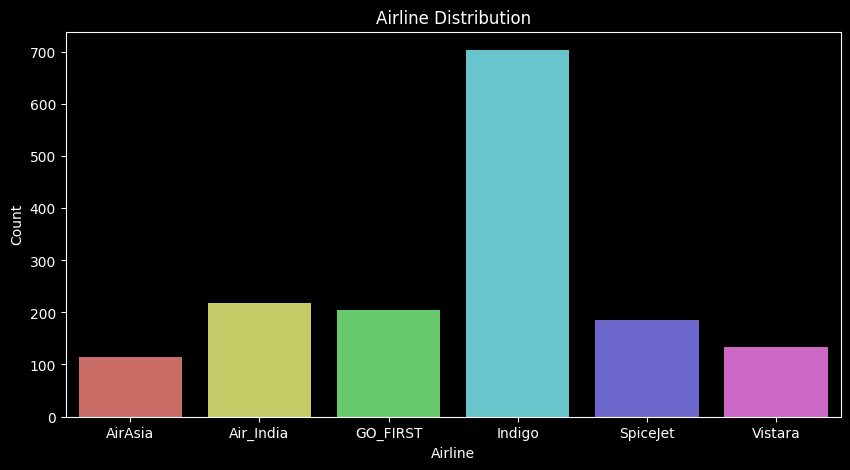

In [29]:
plt.figure(figsize=(10,5))
sns.countplot(data=data1,x='airline',palette='hls')
plt.xticks(rotation=0)
plt.title('Airline Distribution')
plt.xlabel('Airline')
plt.ylabel('Count')
plt.show()

In [30]:
data2 = data.groupby(['flight','airline','class'],as_index=False).count()
data2['class'].value_counts()

class
Economy     1560
Business     295
Name: count, dtype: int64

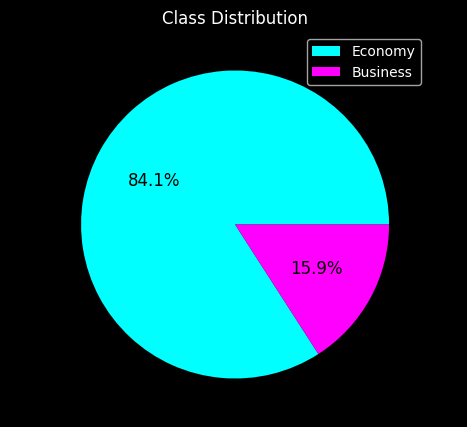

In [31]:
plt.figure(figsize=(10,5))
data2['class'].value_counts().plot(kind='pie',autopct='%1.1f%%',textprops={'fontsize': 12, 'color': 'black'},cmap = 'cool')
plt.title('Class Distribution')
plt.legend()
plt.show()

C:\Users\mejba\AppData\Local\Temp\ipykernel_16624\2892791019.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=data['airline'],y=data['price'],palette='hls')


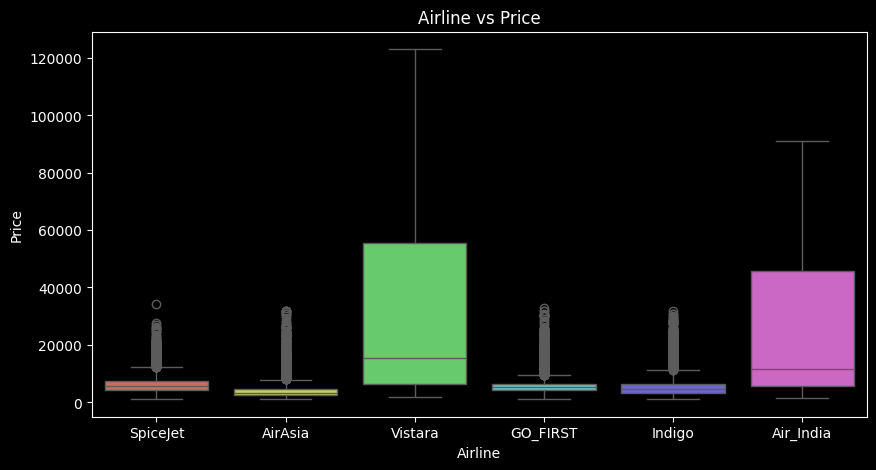

In [32]:
plt.figure(figsize=(10,5))
sns.boxplot(x=data['airline'],y=data['price'],palette='hls')
plt.xticks(rotation=0)
plt.title('Airline vs Price')
plt.xlabel('Airline')
plt.ylabel('Price')
plt.show()

C:\Users\mejba\AppData\Local\Temp\ipykernel_16624\3327350783.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=data['class'],y=data['price'],palette='hls')


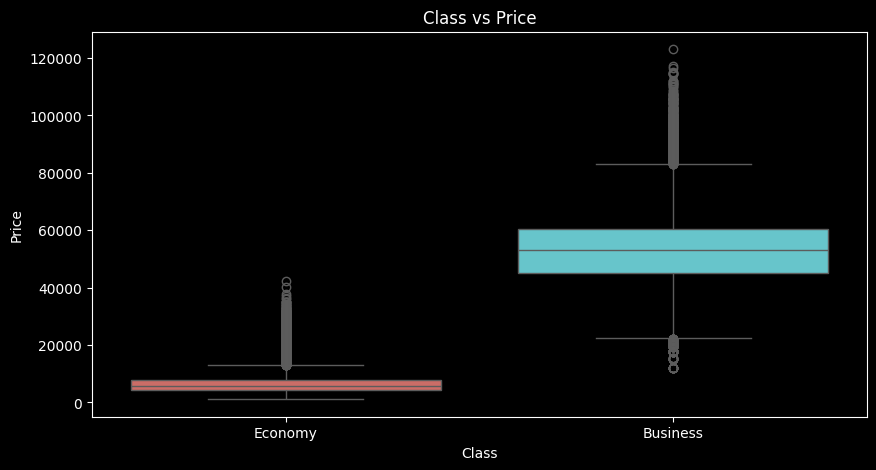

In [33]:
plt.figure(figsize=(10,5))
sns.boxplot(x=data['class'],y=data['price'],palette='hls')
plt.xticks(rotation=0)
plt.title('Class vs Price')
plt.xlabel('Class')
plt.ylabel('Price')
plt.show()

C:\Users\mejba\AppData\Local\Temp\ipykernel_16624\1370490499.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=data['stops'],y=data['price'],palette='hls')


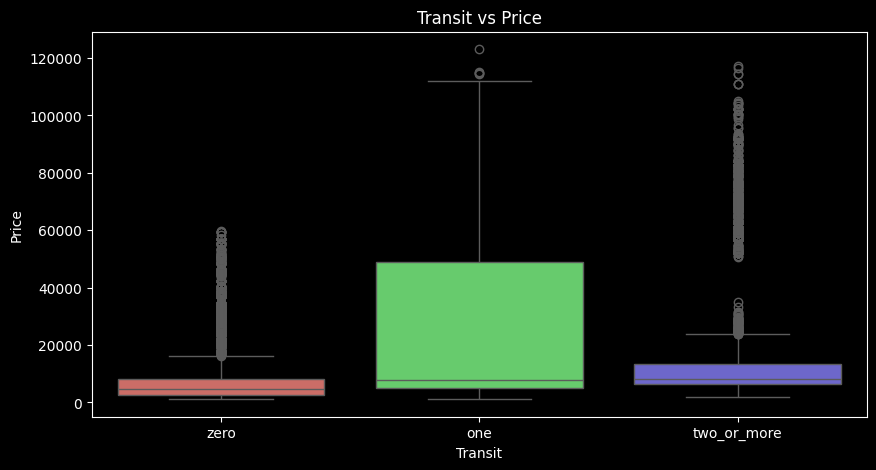

In [34]:
plt.figure(figsize=(10,5))
sns.boxplot(x=data['stops'],y=data['price'],palette='hls')
plt.xticks(rotation=0)
plt.title('Transit vs Price')
plt.xlabel('Transit')
plt.ylabel('Price')
plt.show()

In [35]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 300153 entries, 0 to 300152
Data columns (total 11 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   airline           300153 non-null  str    
 1   flight            300153 non-null  str    
 2   source_city       300153 non-null  str    
 3   departure_time    300153 non-null  str    
 4   stops             300153 non-null  str    
 5   arrival_time      300153 non-null  str    
 6   destination_city  300153 non-null  str    
 7   class             300153 non-null  str    
 8   duration          300153 non-null  float64
 9   days_left         300153 non-null  int64  
 10  price             300153 non-null  int64  
dtypes: float64(1), int64(2), str(8)
memory usage: 40.6 MB


C:\Users\mejba\AppData\Local\Temp\ipykernel_16624\210906588.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=data['departure_time'],y=data['price'],palette='hls')
C:\Users\mejba\AppData\Local\Temp\ipykernel_16624\210906588.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=data['arrival_time'],y=data['price'],palette='hls')


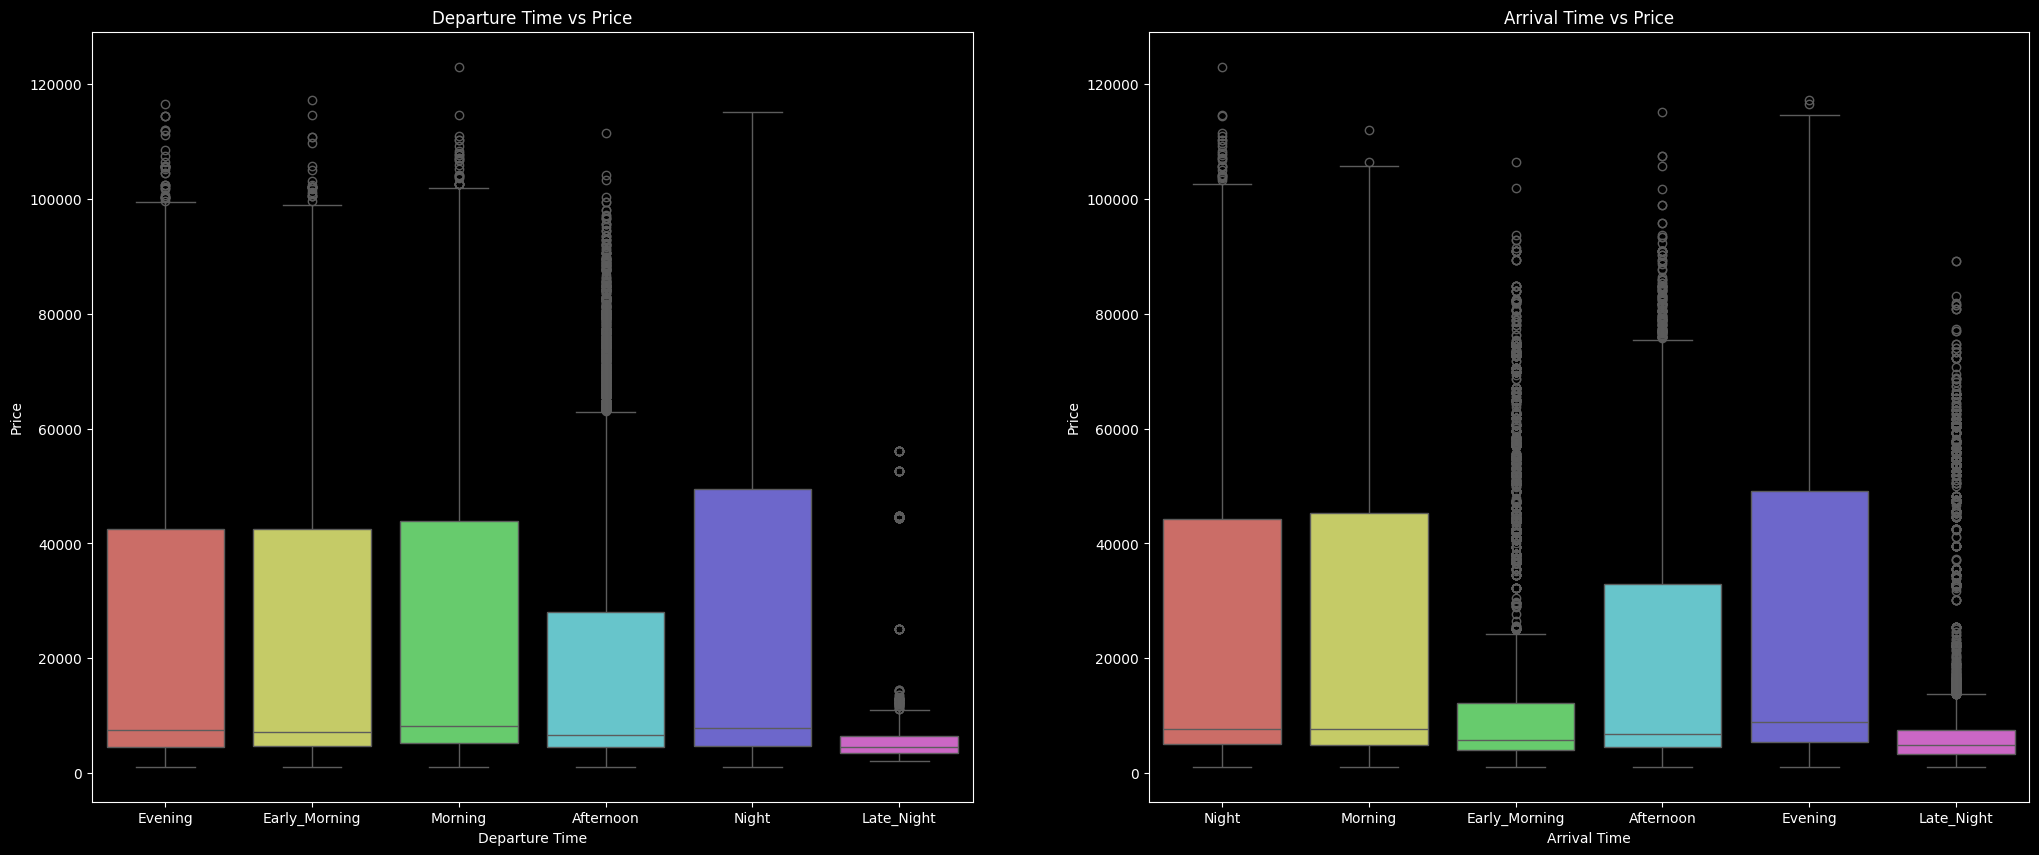

In [36]:
plt.figure(figsize=(25,10))
plt.subplot(1,2,1)
sns.boxplot(x=data['departure_time'],y=data['price'],palette='hls')
plt.title('Departure Time vs Price')
plt.xlabel('Departure Time')
plt.ylabel('Price')
plt.subplot(1,2,2)
sns.boxplot(x=data['arrival_time'],y=data['price'],palette='hls')
plt.title('Arrival Time vs Price')
plt.xlabel('Arrival Time')
plt.ylabel('Price')
# plt.tight_layout()
plt.show()

C:\Users\mejba\AppData\Local\Temp\ipykernel_16624\386246790.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=data['source_city'],y=data['price'],palette='hls')
C:\Users\mejba\AppData\Local\Temp\ipykernel_16624\386246790.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=data['destination_city'],y=data['price'],palette='hls')


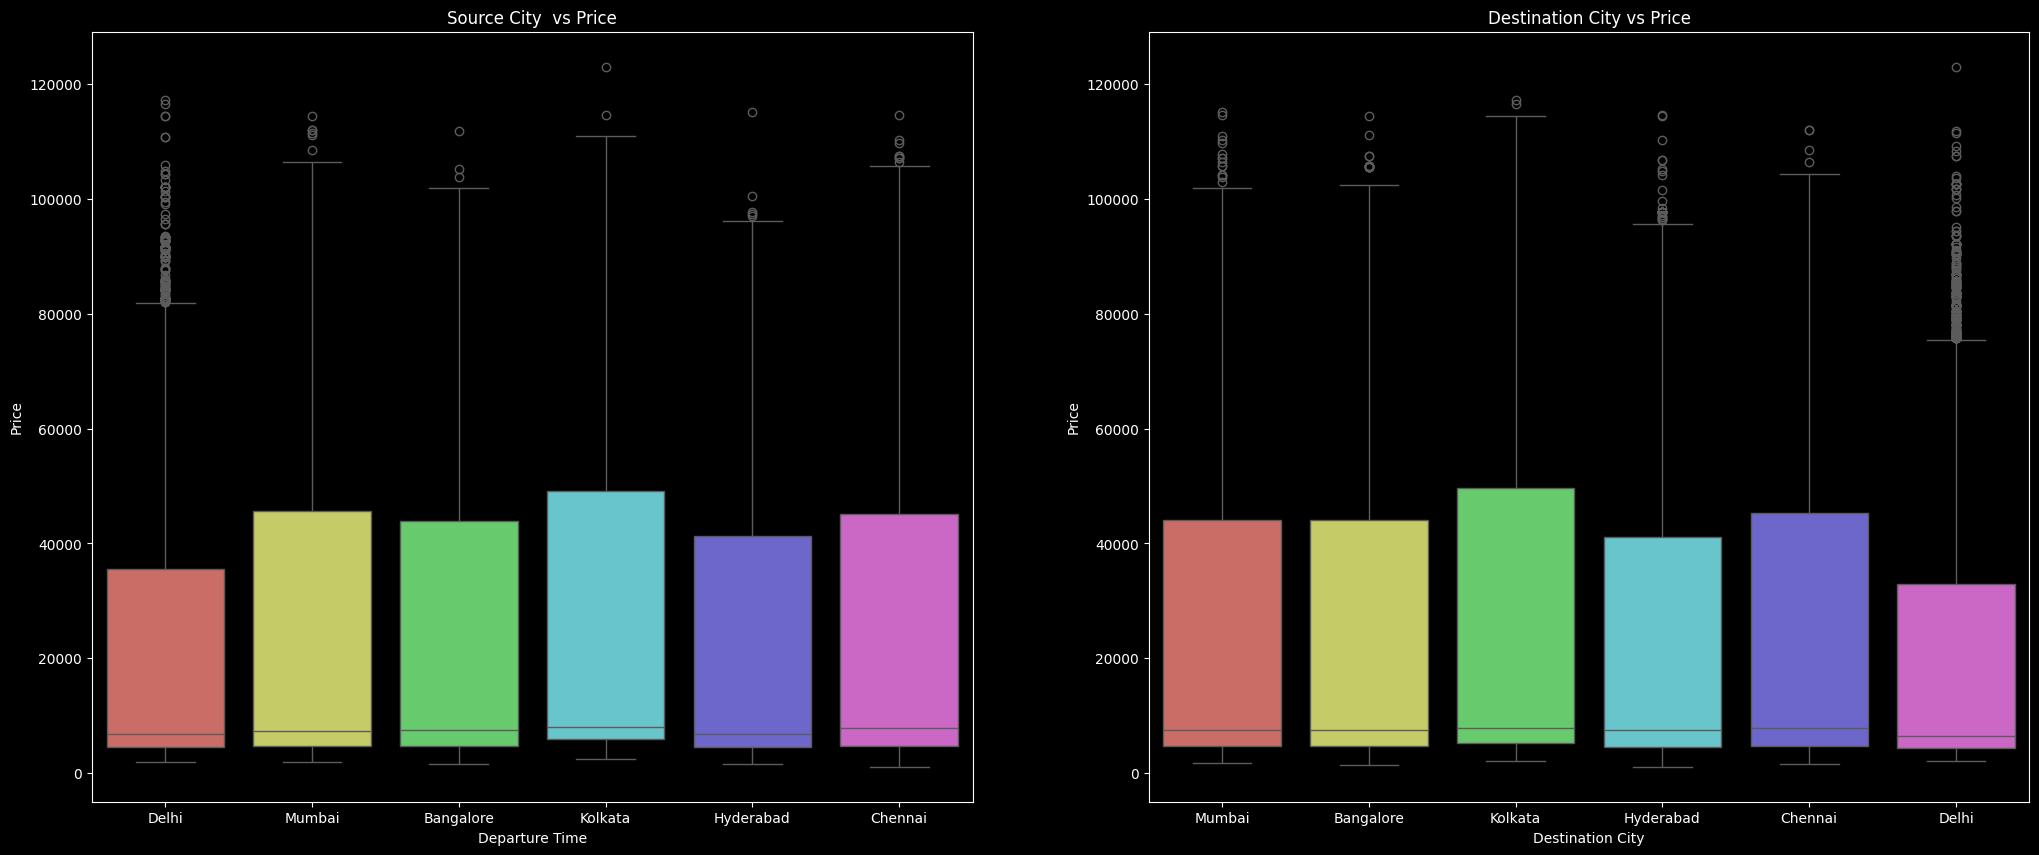

In [37]:
plt.figure(figsize=(25,10))
plt.subplot(1,2,1)
sns.boxplot(x=data['source_city'],y=data['price'],palette='hls')
plt.title('Source City  vs Price')
plt.xlabel('Departure Time')
plt.ylabel('Price')
plt.subplot(1,2,2)
sns.boxplot(x=data['destination_city'],y=data['price'],palette='hls')
plt.title('Destination City vs Price')
plt.xlabel('Destination City')
plt.ylabel('Price')
# plt.tight_layout()
plt.show()

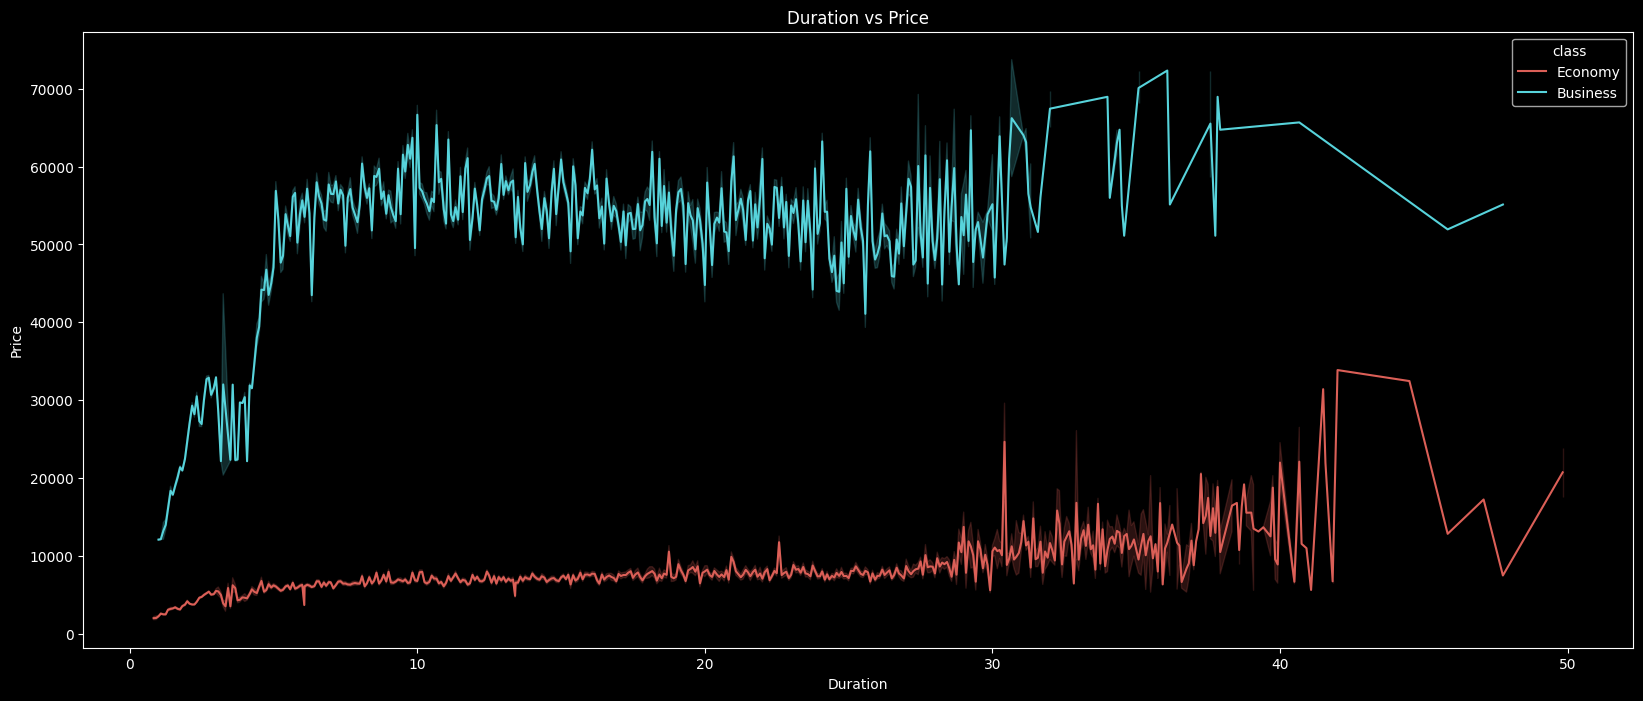

In [38]:
plt.style.use('dark_background')
plt.figure(figsize=(20,8))
sns.lineplot(data=data,x='duration',y='price',hue='class',palette='hls')
plt.title('Duration vs Price')
plt.xlabel('Duration')
plt.ylabel('Price')
plt.show()

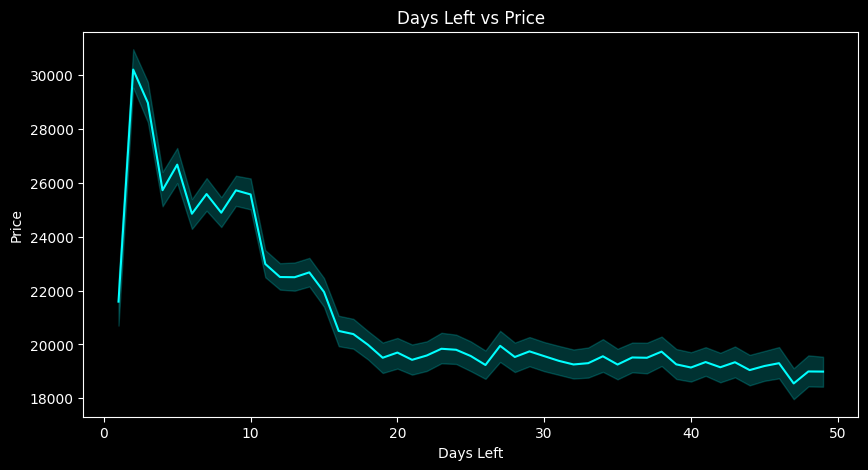

In [39]:
plt.figure(figsize=(10,5))
sns.lineplot(data=data,x='days_left',y='price',color='cyan')
plt.title('Days Left vs Price')
plt.xlabel('Days Left')
plt.ylabel('Price')
plt.show()

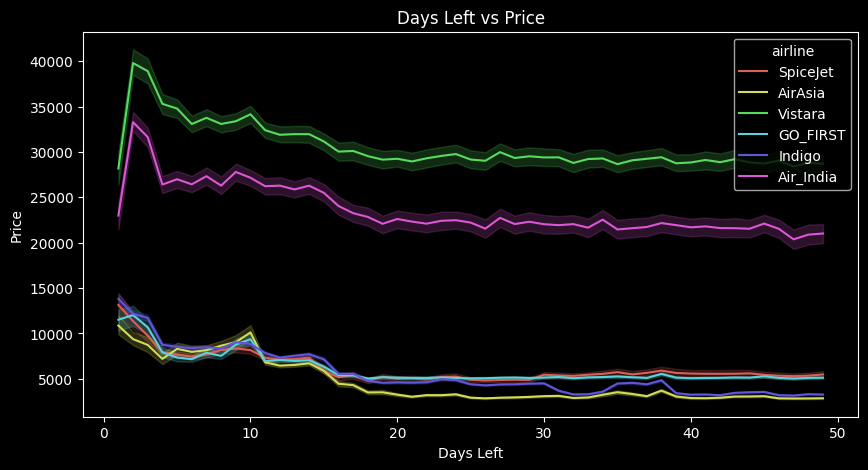

In [40]:
plt.figure(figsize=(10,5))
sns.lineplot(data=data,x='days_left',y='price',color='cyan',hue='airline',palette='hls')
plt.title('Days Left vs Price')
plt.xlabel('Days Left')
plt.ylabel('Price')
plt.show()